In [1]:
import pandas as pd
import seaborn
import os
import math
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import OptimizeWarning
from scipy.optimize import curve_fit
import warnings
import dask.dataframe as dd
from functools import partial
import inspect

sys.path.append(os.path.join(os.path.dirname(
    os.path.abspath(''))))
import common.potential_data as potential_data
import scaler
import common.plots as plots
import common.potential_analyze
import common.fit as fit
import functional

pd.options.mode.chained_assignment = None
warnings.simplefilter("ignore", OptimizeWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [ ]:
def save_image(image_path, image_name, fg, format='png', save_black=False):
    try:
        os.makedirs(image_path)
    except:
        pass

    output_path = f'{image_path}/{image_name}.{format}'
    print(output_path)
    fg.savefig(output_path, dpi=800, facecolor='white', format=format)
    if save_black:
        Image.open(f'{output_path}.png').convert('L').save(f'{output_path}_bw.png')

def make_plot(data, x, y, hue, style, x_label, y_label, title, image_path, image_name, show_plot, err=None, df_fits=None, black_line_y=None, dashed_line_y=None, markers_different=False, color_palette='bright', save_figure=False, x_log=False, y_log=False):
    markers_arr = ['o', '^', 's', 'D', 'P', 'X', 'v', '*']
    if hue is not None:
        hues = data[hue].unique()
        n_colors = hues.shape[0]
        color_palette = seaborn.color_palette(palette=color_palette, n_colors=n_colors)
        potential_type_hue = dict(zip(data[hue].unique(), hues))
        color_palette = dict(zip(hues, color_palette))
        markers_hue = markers_arr[:len(hues)]
    else:
        color_palette = None
        markers_hue = None
    #hue_kws=dict(marker=markers_hue)
    fg_kws = {}
    if markers_different:
        fg_kws['hue_kws'] = dict(marker=markers_hue)
    fg = seaborn.FacetGrid(data=data, hue=hue, style=style, height=5,
                           aspect=1.6, palette=color_palette, legend_out=False, **fg_kws)
    if err is not None:
        fg.map(plt.errorbar, x, y, err, mfc=None, fmt='o', ms=3, capsize=5, lw=0.5, ls=None
           ).add_legend()
    else:
        fg.map(plt.errorbar, x, y, mfc=None, fmt='o', ms=3, capsize=5, lw=0.5, ls=None
           ).add_legend()
    fg.add_legend()
    # seaborn.move_legend(fg)
    fg.legend.set_title("")
    if x_log:
        fg.ax.set_xscale('log')
    if y_log:
        fg.ax.set_yscale('log')
    fg.ax.set_xlabel(x_label, fontsize=14)
    fg.ax.set_ylabel(y_label, fontsize=14)
    fg.ax.set_title(title)
    fg.ax.spines['right'].set_visible(True)
    fg.ax.spines['top'].set_visible(True)
    fg.ax.minorticks_on()
    fg.ax.tick_params(which='both', bottom=True,
                      top=True, left=True, right=True)
    # plt.grid(dash_capstyle='round')
    if black_line_y is not None:
        plt.axhline(y=black_line_y, color='black', linestyle='-')

    if dashed_line_y is not None:
        for coord in dashed_line_y:
            plt.axhline(y=coord, color='r', linestyle='--')

    if df_fits is not None:
        for key in df_fits[hue].unique():
            if key == 'mon' or key == 'mod':
                plt.plot(df_fits[df_fits[hue] == key][x], df_fits[df_fits[hue] == key][y],
                     color=color_palette[potential_type_hue[key]], linewidth=1, linestyle='--')
            else:
                plt.plot(df_fits[df_fits[hue] == key][x], df_fits[df_fits[hue] == key][y],
                     color=color_palette[potential_type_hue[key]], linewidth=1)

    if show_plot:
        plt.show()
    if save_figure:
        save_image(f'{image_path}',
            f'{image_name}', fg)
    return fg

In [12]:
# reading vitaly data files for su2 potential from wilson loops
def read_data_file_original(file_path, size):
    T = []
    r = []
    potential = []
    potential_err = []
    with open(file_path, "r") as file:
        for line in file:
            if line[0] != '#':
                line_tmp = line.strip()
                line_tmp = line_tmp.split()
                r += [int(line_tmp[0])] * (size - 1)
                T += list(range(1, size))
                line_tmp = list(map(float, line_tmp[1:]))
                potential += line_tmp[:size-1]
                potential_err += line_tmp[size-1:]
    return pd.DataFrame({'T': T, 'r/a': r, 'aV(r)': potential, 'err': potential_err})

def read_data_file_decomposed(file_path, size):
    T = []
    r = []
    potential = []
    potential_err = []
    decomposition_type = []
    with open(file_path, "r") as file:
        for line in file:
            if line[0] != '#':
                line = line.strip()
                line = line.split()
                r += [int(line[0])] * 2 * (size - 1)
                T += list(range(1, size))
                T += list(range(1, size))
                line_tmp = list(map(float, line[1:2 * size - 1]))
                potential += line_tmp[:size-1]
                potential_err += line_tmp[size-1:]
                decomposition_type += ['mon'] * (size - 1)
                line_tmp = list(map(float, line[2 * size:4 * size - 2]))
                potential += line_tmp[:size-1]
                potential_err += line_tmp[size-1:]
                decomposition_type += ['mod'] * (size - 1)
    return pd.DataFrame({'T': T, 'r/a': r, 'aV(r)': potential, 'err': potential_err, 'decomposition_type': decomposition_type})

def read_data_vitaly_fundamental():
    df = []
    df.append(read_data_file_original('../../data/DATA_SU2/B2p4_L24/FUND/pot_vs_r_50nsm_nab.dat', 12))
    df[-1]['decomposition_type'] = 'SU(2)'
    df[-1]['beta'] = 2.4
    df[-1]['Ns'] = 24
    df.append(read_data_file_decomposed('../../data/DATA_SU2/B2p4_L24/FUND/pot_vs_r_both.dat', 12))
    df[-1]['beta'] = 2.4
    df[-1]['Ns'] = 24
    df.append(read_data_file_original('../../data/DATA_SU2/B2p5_L24/FUND/pot_vs_r_50nsm_nab.dat', 12))
    df[-1]['decomposition_type'] = 'SU(2)'
    df[-1]['beta'] = 2.5
    df[-1]['Ns'] = 24
    df.append(read_data_file_decomposed('../../data/DATA_SU2/B2p5_L24/FUND/pot_vs_r_both.dat', 12))
    df[-1]['beta'] = 2.5
    df[-1]['Ns'] = 24
    df.append(read_data_file_original('../../data/DATA_SU2/B2p6_L32/FUND/pot_vs_r_50nsm_nab.dat', 16))
    df[-1]['decomposition_type'] = 'SU(2)'
    df[-1]['beta'] = 2.6
    df[-1]['Ns'] = 32
    df.append(read_data_file_decomposed('../../data/DATA_SU2/B2p6_L32/FUND/pot_vs_r_both_L32.dat', 16))
    df[-1]['beta'] = 2.6
    df[-1]['Ns'] = 32
    return pd.concat(df)

def read_data_vitaly_adjoint():
    df = []
    df.append(read_data_file_original('../../data/DATA_SU2/B2p4_L24/ADJ/pot_vs_r_adj_100nsm_nab.dat', 12))
    df[-1]['decomposition_type'] = 'SU(2)'
    df[-1]['beta'] = 2.4
    df[-1]['Ns'] = 24
    df.append(read_data_file_decomposed('../../data/DATA_SU2/B2p4_L24/ADJ/pot_vs_r_both_adj_b2p4.dat', 12))
    df[-1]['beta'] = 2.4
    df[-1]['Ns'] = 24
    df.append(read_data_file_original('../../data/DATA_SU2/B2p5_L24/ADJ/pot_vs_r_adj_100nsm.dat', 12))
    df[-1]['decomposition_type'] = 'SU(2)'
    df[-1]['beta'] = 2.5
    df[-1]['Ns'] = 24
    df.append(read_data_file_decomposed('../../data/DATA_SU2/B2p5_L24/ADJ/pot_vs_r_both_adj_b2p5.dat', 12))
    df[-1]['beta'] = 2.5
    df[-1]['Ns'] = 24
    df.append(read_data_file_original('../../data/DATA_SU2/B2p6_L32/ADJ/pot_vs_r_100nsm_adj_nab.dat', 16))
    df[-1]['decomposition_type'] = 'SU(2)'
    df[-1]['beta'] = 2.6
    df[-1]['Ns'] = 32
    df.append(read_data_file_decomposed('../../data/DATA_SU2/B2p6_L32/ADJ/pot_vs_r_adj_both_b2p6_L32.dat', 16))
    df[-1]['beta'] = 2.6
    df[-1]['Ns'] = 32
    return pd.concat(df)

def read_data_vitaly_improved_fundamental():
    df = []
    df.append(read_data_file_original('../../data/DATA_SU2/B3p4L24/FUND/pot_vs_r_100nsm_nab.dat', 12))
    df[-1]['decomposition_type'] = 'SU(2)'
    df[-1]['beta'] = 3.4
    df[-1]['Ns'] = 24
    df.append(read_data_file_decomposed('../../data/DATA_SU2/B3p4L24/FUND/pot_vs_r_both.dat', 12))
    df[-1]['beta'] = 3.4
    df[-1]['Ns'] = 24
    return pd.concat(df)

def read_data_vitaly_improved_adjoint():
    df = []
    df.append(read_data_file_original('../../data/DATA_SU2/B3p4L24/ADJ/pot_vs_r_adj_200nsm_nab.dat', 12))
    df[-1]['decomposition_type'] = 'SU(2)'
    df[-1]['beta'] = 3.4
    df[-1]['Ns'] = 24
    df.append(read_data_file_decomposed('../../data/DATA_SU2/B3p4L24/ADJ/pot_vs_r_both_adj_b3p4.dat', 12))
    df[-1]['beta'] = 3.4
    df[-1]['Ns'] = 24
    return pd.concat(df)

def read_data_vitaly_QC2D_fundamental():
    df = []
    df.append(read_data_file_original('../../data/DATA_SU2/SU2_dinam_mu0p0/pot_vs_r_140nsm_nab.dat', 16))
    df[-1]['decomposition_type'] = 'SU(2)'
    df[-1]['beta'] = 1.95
    df[-1]['Ns'] = 32
    df.append(read_data_file_decomposed('../../data/DATA_SU2/SU2_dinam_mu0p0/pot_vs_r_both.dat', 16))
    df[-1]['beta'] = 1.95
    df[-1]['Ns'] = 32
    return pd.concat(df)

In [13]:
def filter_beta_fundamental(df):
    return df[((df['decomposition_type'] == 'SU(2)') & (df['beta'] == 2.4) & (df['T'] == 3)) |
                ((df['decomposition_type'] == 'mon') & (df['beta'] == 2.4) & (df['T'] == 5)) |
                ((df['decomposition_type'] == 'mod') & (df['beta'] == 2.4) & (df['T'] == 5)) |
                ((df['decomposition_type'] == 'SU(2)') & (df['beta'] == 2.5) & (df['T'] == 5)) |
                ((df['decomposition_type'] == 'mon') & (df['beta'] == 2.5) & (df['T'] == 5)) |
                ((df['decomposition_type'] == 'mod') & (df['beta'] == 2.5) & (df['T'] == 5)) |
                ((df['decomposition_type'] == 'SU(2)') & (df['beta'] == 2.6) & (df['T'] == 5)) |
                ((df['decomposition_type'] == 'mon') & (df['beta'] == 2.6) & (df['T'] == 7)) |
                ((df['decomposition_type'] == 'mod') & (df['beta'] == 2.6) & (df['T'] == 5))]

def filter_beta_adjoint(df):
    return df[((df['decomposition_type'] == 'SU(2)') & (df['beta'] == 2.4) & (df['T'] == 2)) |
                ((df['decomposition_type'] == 'mon') & (df['beta'] == 2.4) & (df['T'] == 4)) |
                ((df['decomposition_type'] == 'mod') & (df['beta'] == 2.4) & (df['T'] == 3)) |
                ((df['decomposition_type'] == 'SU(2)') & (df['beta'] == 2.5) & (df['T'] == 2)) |
                ((df['decomposition_type'] == 'mon') & (df['beta'] == 2.5) & (df['T'] == 4)) |
                ((df['decomposition_type'] == 'mod') & (df['beta'] == 2.5) & (df['T'] == 3)) |
                ((df['decomposition_type'] == 'SU(2)') & (df['beta'] == 2.6) & (df['T'] == 3)) |
                ((df['decomposition_type'] == 'mon') & (df['beta'] == 2.6) & (df['T'] == 7)) |
                ((df['decomposition_type'] == 'mod') & (df['beta'] == 2.6) & (df['T'] == 3))]

def filter_improved_fundamental(df):
    return df[((df['decomposition_type'] == 'SU(2)') & (df['beta'] == 3.4) & (df['T'] == 4)) |
                ((df['decomposition_type'] == 'mon') & (df['beta'] == 3.4) & (df['T'] == 5)) |
                ((df['decomposition_type'] == 'mod') & (df['beta'] == 3.4) & (df['T'] == 5))]

def fit_parameters_vitaly_fundamental():
    return pd.DataFrame({'beta': [2.4, 2.5, 2.6],
                        'V0': [2.27431782043408, 3.11047268367933, 3.90052700644607],
                        'alpha': [-0.314333209515378, -0.296487127817609, -0.262720856809114],
                        'sigma': [1.0, 1.0, 1.0]})

def fit_parameters_vitaly_adjoint():
    return pd.DataFrame({'beta': [2.4, 2.5, 2.6],
                        'V0': [5.39276534400225, 8.34517454430445, 11.8860623991219],
                        'alpha': [-0.609069943170455, -0.803638190151815, -0.795976273857096],
                        'sigma': [2.82289564169593, 2.34558995534092, 1.80404073977907]})

In [ ]:
def fit_mod(df, df_fit):
    beta = df.name
    fit_func = lambda x, V0: V0 + df_fit[df_fit['beta'] == beta]['alpha'].to_numpy()[0] / x
    popt, pcov = curve_fit(fit_func, df['r/a'], df['aV(r)'], sigma=df['err'], absolute_sigma=True)
    return pd.DataFrame({'V0': [popt[0]], 'V0_err': [pcov[0][0]]})

def fit_combined(x_combined, V0_mod, V0, alpha, sigma):
    n1 = len(x_combined) // 2
    x_1 = x_combined[:n1]
    x_2 = x_combined[n1:]
    y_pred_1 = fit.func_coloumb(x_1, V0, alpha)
    y_pred_2 = fit.func_linear(x_2, V0-V0_mod, sigma)
    return np.concatenate([y_pred_1, y_pred_2])

def fit_mon_mod(df, df_fit):
    beta = df.name
    custom_dict = {'mod':0, 'mon':1}
    df = df.sort_values(
    by=['decomposition_type', 'r/a'],
    ascending=[True, True],
    key=lambda x: x.map(custom_dict) if x.name == 'decomposition_type' else x)
    popt, pcov = curve_fit(partial(fit_combined, V0=df_fit[df_fit['beta'] == beta]['V0'].to_numpy()[0],
                            alpha=df_fit[df_fit['beta'] == beta]['alpha'].to_numpy()[0],
                            sigma=df_fit[df_fit['beta'] == beta]['sigma'].to_numpy()[0]),
                            df['r/a'], df['aV(r)'], sigma=df['err'], absolute_sigma=True)
    return pd.DataFrame({'V0': [popt[0]], 'V0_err': [pcov[0][0]]})

def remove_T_fit(df):
    df_mon = df[df['decomposition_type'] == 'mon']
    df_mon = df_mon[df_mon['T'] == 6]
    df_mon = df_mon.drop('T', axis = 1)
    df_mon = df_mon.drop('Ns', axis = 1)
    df_mon = df_mon.sort_values(by=['r/a', 'beta'])
    df_nonmon = df[df['decomposition_type'] != 'mon']
    df_nonmon = df_nonmon.groupby(['decomposition_type', 'beta', 'r/a']).apply(fit.potential_fit_T_range, fit.func_exponent, ['V', 'a', 'b'], 5, include_groups=False).reset_index(level=['decomposition_type', 'beta', 'r/a']).reset_index(level=-1, drop=True)
    df_mod = df_nonmon[df_nonmon['decomposition_type'] == 'mod']
    df_mod = df_mod.sort_values(by=['T', 'r/a', 'beta'])
    df_sum = df_mon.copy()
    df_sum['decomposition_type'] = 'mon+mod'
    df_sum.loc[:, 'err'] = np.sqrt(df_mon.loc[:, 'err'].array**2 + df_mod.loc[:, 'err'].array**2)
    df_sum.loc[:, 'aV(r)'] = df_mon.loc[:, 'aV(r)'].array + df_mod.loc[:, 'aV(r)'].array
    df = pd.concat([df_nonmon, df_mon, df_sum])
    custom_dict = {'SU(2)':0, 'mon':1, 'mod':3, 'mon+mod': 4}
    df = df.sort_values(by=['decomposition_type'], key=lambda x: x.map(custom_dict))
    return df

def remove_T_filter(df, filter_function):
    df = filter_function(df)
    df = df.drop('T', axis = 1)
    df = df.drop('Ns', axis = 1)
    df_mon = df[df['decomposition_type'] == 'mon']
    df_mon = df_mon.sort_values(by=['r/a', 'beta'])
    df_mod = df[df['decomposition_type'] == 'mod']
    df_mod = df_mod.sort_values(by=['r/a', 'beta'])
    df_sum = df_mon.copy()
    df_sum['decomposition_type'] = 'mon+mod'
    df_sum.loc[:, 'err'] = np.sqrt(df_mon.loc[:, 'err'].array**2 + df_mod.loc[:, 'err'].array**2)
    df_sum.loc[:, 'aV(r)'] = df_mon.loc[:, 'aV(r)'].array + df_mod.loc[:, 'aV(r)'].array
    df = pd.concat([df, df_sum])
    custom_dict = {'SU(2)':0, 'mon':1, 'mod':3, 'mon+mod': 4}
    df = df.sort_values(by=['decomposition_type'], key=lambda x: x.map(custom_dict))
    return df

def fit_r_all(df):
    df_fit = df.groupby(['decomposition_type', 'beta']).apply(fit.make_fit_range, fit.func_cornell, ['V0', 'alpha', 'sigma'], 'r/a', 'aV(r)', 'err', range_min_len=8, include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
    df_fit = df_fit.groupby(['decomposition_type', 'beta']).apply(fit.average_fit_p_value, ['V0', 'alpha', 'sigma'], 'r/a', include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
    return df_fit

def fit_r_original_sum(df):
    df_su2 = df[~df['decomposition_type'].isin(['mon', 'mod'])]
    df_fit = df_su2[df_su2['r/a'] > 2].groupby(['decomposition_type', 'beta']).apply(fit.make_fit_range, fit.func_cornell, ['V0', 'alpha', 'sigma'], 'r/a', 'aV(r)', 'err', range_min_len=8, include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
    df_fit = df_fit.groupby(['decomposition_type', 'beta']).apply(fit.average_fit_p_value, ['V0', 'alpha', 'sigma'], 'r/a', include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
    df_fit['r/a_min'] = 1
    df_fit_V0 = df[(df['decomposition_type'].isin(['mod', 'mon'])) & (df['r/a'] > 2)].groupby('beta').apply(fit_mon_mod, df_fit[df_fit['decomposition_type'] == 'SU(2)'], include_groups=False).reset_index(level='beta').reset_index(level=-1, drop=True)
    df_fit_V0['r/a_min'] = 1
    df_fit_mod = df_fit[df_fit['decomposition_type'] == 'SU(2)']
    df_fit_mod['decomposition_type'] = 'mod'
    df_fit_mod['sigma'] = 0
    df_fit_mod['sigma_err'] = 0
    df_fit_mod['V0'] = df_fit_V0['V0']
    df_fit_mod['V0_err'] = df_fit_V0['V0_err']
    df_fit_mon = df_fit[df_fit['decomposition_type'] == 'SU(2)']
    df_fit_mon['decomposition_type'] = 'mon'
    df_fit_mon['alpha'] = 0
    df_fit_mon['alpha_err'] = 0
    df_fit_mon['V0'] = df_fit_mon['V0'] - df_fit_V0['V0']
    df_fit_mon['V0_err'] = df_fit_mon['V0_err']**2 + df_fit_V0['V0_err']**2
    df_fit = pd.concat([df_fit, df_fit_mon, df_fit_mod])
    return df_fit

def fit_r_original_sum_custom(df, custom_fit_func):
    df_su2 = df[~df['decomposition_type'].isin(['mon', 'mod'])]
    df_fit = df_su2.groupby(['decomposition_type', 'beta']).apply(fit.make_fit_range, fit.func_cornell, ['V0', 'alpha', 'sigma'], 'r/a', 'aV(r)', 'err', range_min_len=8, include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
    df_fit = df_fit.groupby(['decomposition_type', 'beta']).apply(fit.average_fit_p_value, ['V0', 'alpha', 'sigma'], 'r/a', include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
    df_fit_vitaly = custom_fit_func()
    weights = df_fit_vitaly['beta'].map(sigma)
    df_fit_vitaly['V0'] = df_fit_vitaly['V0'].mul(weights, axis=0)
    df_fit_vitaly['sigma'] = df_fit_vitaly['sigma'].mul(weights, axis=0).mul(weights, axis=0)
    df_fit.loc[df_fit['decomposition_type'] == 'SU(2)', ['beta', 'V0', 'alpha', 'sigma']] = df_fit_vitaly.loc[:, ['beta', 'V0', 'alpha', 'sigma']]
    df_fit_V0 = df[(df['decomposition_type'].isin(['mod', 'mon'])) & (df['r/a'] > 3)].groupby('beta').apply(fit_mon_mod, df_fit[df_fit['decomposition_type'] == 'SU(2)'], include_groups=False).reset_index(level='beta').reset_index(level=-1, drop=True)
    df_fit_mod = df_fit[df_fit['decomposition_type'] == 'SU(2)']
    df_fit_mod['decomposition_type'] = 'mod'
    df_fit_mod['sigma'] = 0
    df_fit_mod['sigma_err'] = 0
    df_fit_mod['V0'] = df_fit_V0['V0']
    df_fit_mod['V0_err'] = df_fit_V0['V0_err']
    df_fit_mon = df_fit[df_fit['decomposition_type'] == 'SU(2)']
    df_fit_mon['decomposition_type'] = 'mon'
    df_fit_mon['alpha'] = 0
    df_fit_mon['alpha_err'] = 0
    df_fit_mon['V0'] = df_fit_mon['V0'] - df_fit_V0['V0']
    df_fit_mon['V0_err'] = df_fit_mon['V0_err']**2 + df_fit_V0['V0_err']**2
    df_fit = pd.concat([df_fit, df_fit_mon, df_fit_mod])
    return df_fit

def rescale_df(df, df_curves, sigma):
    weights = df['beta'].map(sigma)
    df['r/a'] = df['r/a'].mul(weights, axis=0)
    df['aV(r)'] = df['aV(r)'].div(weights, axis=0)
    df['err'] = df['err'].div(weights, axis=0)
    weights = df_curves['beta'].map(sigma)
    df_curves['r/a'] = df_curves['r/a'].mul(weights, axis=0)
    df_curves['aV(r)'] =  df_curves['aV(r)'].div(weights, axis=0)
    return df, df_curves

def plot_decomposition(remove_T_func, fit_r_func, pool, representation_name, sigma):
    sig = inspect.signature(remove_T_func)
    filtered_kwargs = {k: v for k, v in pool.items() if k in sig.parameters}
    df = remove_T_func(**filtered_kwargs)
    # print(df)
    sig = inspect.signature(fit_r_func)
    filtered_kwargs = {k: v for k, v in pool.items() if k in sig.parameters and k != 'df'}
    df_fit = fit_r_func(df, **filtered_kwargs)
    # print(df_fit)
    df_curves = df_fit.groupby(['decomposition_type', 'beta']).apply(fit.make_fit_curve, fit.func_cornell, 'r/a', 'aV(r)', ['V0', 'alpha', 'sigma'], include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
    df, df_curves = rescale_df(df, df_curves, sigma)
    for beta in df['beta'].unique():
        make_plot(df[df['beta'] == beta], 'r/a', 'aV(r)', 'decomposition_type', r'$r\sqrt{\sigma}$', r'$V(r)/\sqrt{\sigma}$', '', '../../images/potential_decomposition/su2/gluodynamics/su2_suzuki', f'potential_decomposition_{representation_name}_beta={beta}', True, err='err', df_fits=df_curves[df_curves['beta'] == beta], save_figure=True)

def plot_decomposition_delta(remove_T_func, pool, representation_name, sigma):
    sig = inspect.signature(remove_T_func)
    filtered_kwargs = {k: v for k, v in pool.items() if k in sig.parameters}
    df = remove_T_func(**filtered_kwargs)
    df_su2 = df[df['decomposition_type'] == 'SU(2)'].sort_values(by=['r/a', 'beta'])
    df_sum = df[df['decomposition_type'] == 'mon+mod'].sort_values(by=['r/a', 'beta'])
    df_su2['err'] = np.sqrt((df_su2['err'].array / df_su2['aV(r)'].array)**2 + (df_sum['err'].array / df_sum['aV(r)'].array)**2) * df_su2['aV(r)'].array
    df_su2['aV(r)'] = (df_su2['aV(r)'].array - df_sum['aV(r)'].array) / df_su2['aV(r)'].array
    print(df_su2)
    make_plot(df_su2, 'r/a', 'aV(r)', 'beta', r'$r\sqrt{\sigma}$', r'$\Delta$', '', '../../images/potential_decomposition/su2/gluodynamics/su2_suzuki', f'potential_decomposition_delta_{representation_name}', True, err='err', save_figure=True, black_line_y=0)

def plot_decomposition_original_sum(remove_T_func, fit_r_func, pool, representation_name, sigma):
    sig = inspect.signature(remove_T_func)
    filtered_kwargs = {k: v for k, v in pool.items() if k in sig.parameters}
    df = remove_T_func(**filtered_kwargs)
    sig = inspect.signature(fit_r_func)
    filtered_kwargs = {k: v for k, v in pool.items() if k in sig.parameters and k != 'df'}
    df_fit = fit_r_func(df, **filtered_kwargs)
    df_curves = df_fit.groupby(['decomposition_type', 'beta']).apply(fit.make_fit_curve, fit.func_cornell, 'r/a', 'aV(r)', ['V0', 'alpha', 'sigma'], include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
    df, df_curves = rescale_df(df, df_curves, sigma)
    df = df
    for beta in df['beta'].unique():
        make_plot(df, 'r/a', 'aV(r)', 'decomposition_type', r'$r\sqrt{\sigma}$', r'$V(r)/\sqrt{\sigma}$', '', '../../images/potential_decomposition/su2/gluodynamics/su2_suzuki', f'potential_decomposition_{representation_name}_beta={beta}', True, err='err', df_fits=df_curves[df_curves['beta'] == beta], save_figure=True)

# def plot_decomposition(df, representation_name, sigma):
#     df = remove_T_fit(df)
#     df_fit = fit_r_all(df)
#     df_curves = df_fit.groupby(['decomposition_type', 'beta']).apply(fit.make_fit_curve, fit.func_cornell, 'r/a', 'aV(r)', ['V0', 'alpha', 'sigma'], include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
#     df, df_curves = rescale_df(df, df_curves, sigma)
#     for beta in df['beta'].unique():
#         make_plot(df[df['beta'] == beta], 'r/a', 'aV(r)', 'decomposition_type', r'$r\sqrt{\sigma}$', r'$V(r)/\sqrt{\sigma}$', '', '../../images/potential_decomposition/su2/gluodynamics/su2_suzuki', f'potential_decomposition_{representation_name}_beta={beta}', True, err='err', df_fits=df_curves[df_curves['beta'] == beta], save_figure=True)

# def plot_decomposition_T(df, filter_function, sigma):
#     df = remove_T_filter(df, filter_function)
#     df_fit = fit_r_original_sum(df)
#     df_curves = df_fit.groupby(['decomposition_type', 'beta']).apply(fit.make_fit_curve, fit.func_cornell, 'r/a', 'aV(r)', ['V0', 'alpha', 'sigma'], include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
#     df, df_curves = rescale_df(df, df_curves, sigma)
#     for beta in df['beta'].unique():
#         make_plot(df[df['beta'] == beta], 'r/a', 'aV(r)', 'decomposition_type', r'$r\sqrt{\sigma}$', r'$V(r)/\sqrt{\sigma}$', '', '../../images/potential_decomposition/su2/gluodynamics/su2_suzuki', f'potential_decomposition_fundamental_beta={beta}_T', True, err='err', df_fits=df_curves[df_curves['beta'] == beta], save_figure=True)

# def plot_decomposition_T_vitaly_fit(df, representation_name, filter_function, custom_fit_func, sigma):
#     df = remove_T_filter(df, filter_function)
#     df_fit = fit_r_original_sum_custom(df, custom_fit_func)
#     df_curves = df_fit.groupby(['decomposition_type', 'beta']).apply(fit.make_fit_curve, fit.func_cornell, 'r/a', 'aV(r)', ['V0', 'alpha', 'sigma'], include_groups=False).reset_index(level=['decomposition_type', 'beta']).reset_index(level=-1, drop=True)
#     df, df_curves = rescale_df(df, df_curves, sigma)
#     for beta in df['beta'].unique():
#         make_plot(df[df['beta'] == beta], 'r/a', 'aV(r)', 'decomposition_type', r'$r\sqrt{\sigma}$', r'$V(r)/\sqrt{\sigma}$', '', '../../images/potential_decomposition/su2/gluodynamics/su2_suzuki', f'potential_decomposition_{representation_name}_beta={beta}_T', True, err='err', df_fits=df_curves[df_curves['beta'] == beta], save_figure=True)

     r/a     aV(r)       err decomposition_type  beta
2      1 -0.077063  0.000374              SU(2)   2.4
4      1 -0.040494  0.000461              SU(2)   2.5
4      1 -0.017966  0.000216              SU(2)   2.6
13     2 -0.044691  0.001020              SU(2)   2.4
15     2 -0.026282  0.001123              SU(2)   2.5
19     2 -0.012018  0.000538              SU(2)   2.6
24     3 -0.014227  0.001542              SU(2)   2.4
26     3 -0.010333  0.001826              SU(2)   2.5
34     3 -0.007737  0.000769              SU(2)   2.6
35     4  0.004695  0.002324              SU(2)   2.4
37     4  0.003366  0.002614              SU(2)   2.5
49     4 -0.004351  0.001055              SU(2)   2.6
46     5  0.019855  0.003152              SU(2)   2.4
48     5  0.011230  0.003550              SU(2)   2.5
64     5 -0.003404  0.001180              SU(2)   2.6
57     6  0.031390  0.004505              SU(2)   2.4
59     6  0.019096  0.004568              SU(2)   2.5
79     6  0.001099  0.001408

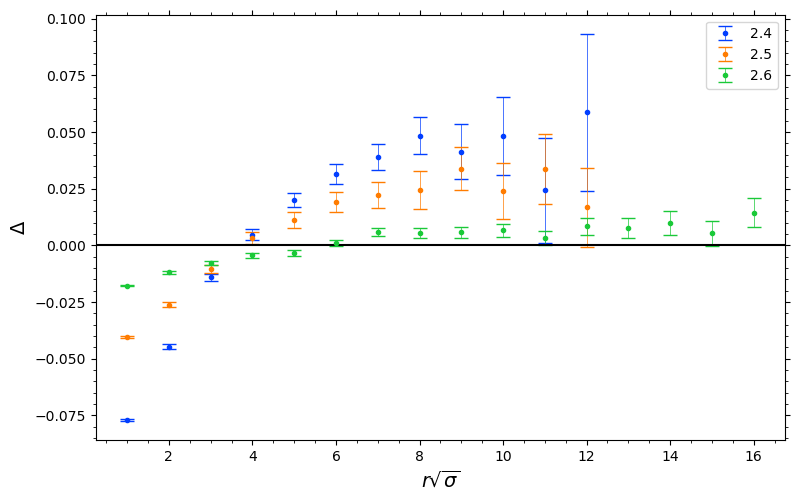

../../images/potential_decomposition/su2/gluodynamics/su2_suzuki/potential_decomposition_delta_fundamental.png


In [20]:
df = read_data_vitaly_fundamental()
df = df[(df['aV(r)'] != 0) & (df['T'] <= 8)]
sigma = {2.4: 0.258265, 2.5: 0.181839, 2.6: 0.1347252}
pool = {'df': df, 'filter_function': filter_beta_fundamental}
plot_decomposition_delta(remove_T_filter, pool, 'fundamental', sigma)

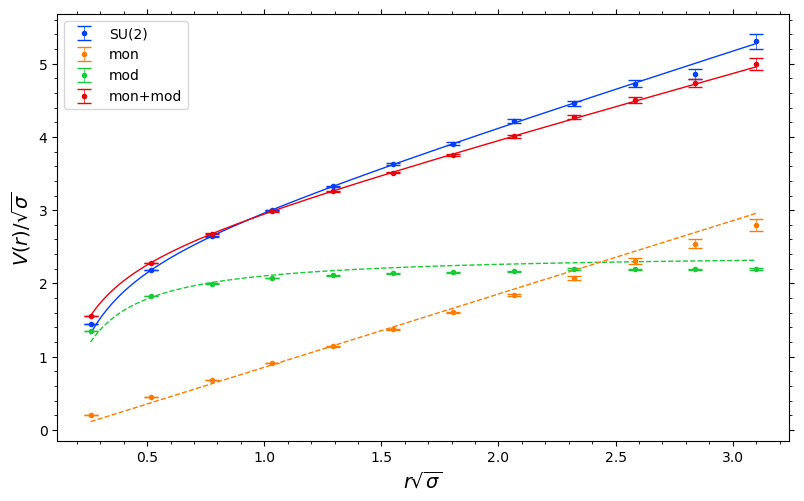

../../images/potential_decomposition/su2/gluodynamics/su2_suzuki/potential_decomposition_fundamental_beta=2.4.png


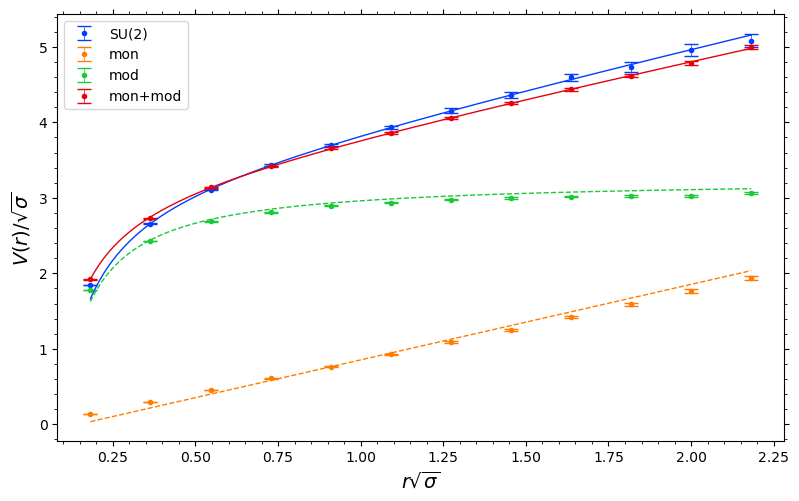

../../images/potential_decomposition/su2/gluodynamics/su2_suzuki/potential_decomposition_fundamental_beta=2.5.png


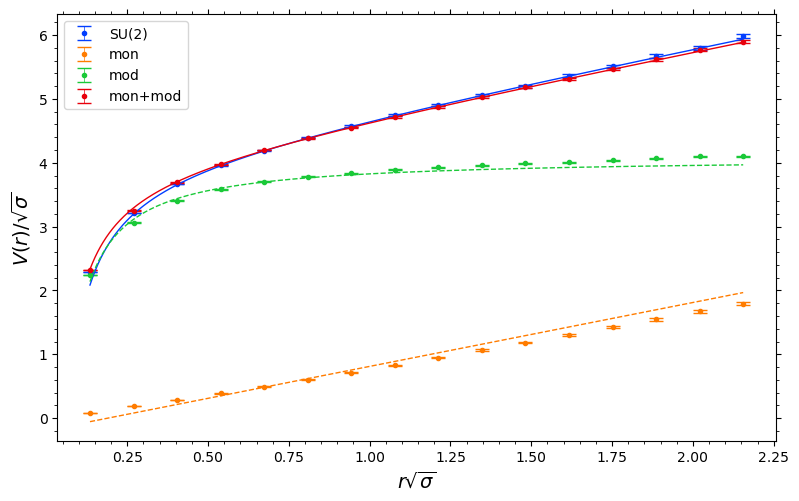

../../images/potential_decomposition/su2/gluodynamics/su2_suzuki/potential_decomposition_fundamental_beta=2.6.png


In [16]:
df = read_data_vitaly_fundamental()
df = df[(df['aV(r)'] != 0) & (df['T'] <= 8)]
sigma = {2.4: 0.258265, 2.5: 0.181839, 2.6: 0.1347252}
pool = {'df': df, 'filter_function': filter_beta_fundamental, 'custom_fit_func': fit_parameters_vitaly_fundamental}
plot_decomposition(remove_T_filter, fit_r_original_sum_custom, pool, 'fundamental', sigma)

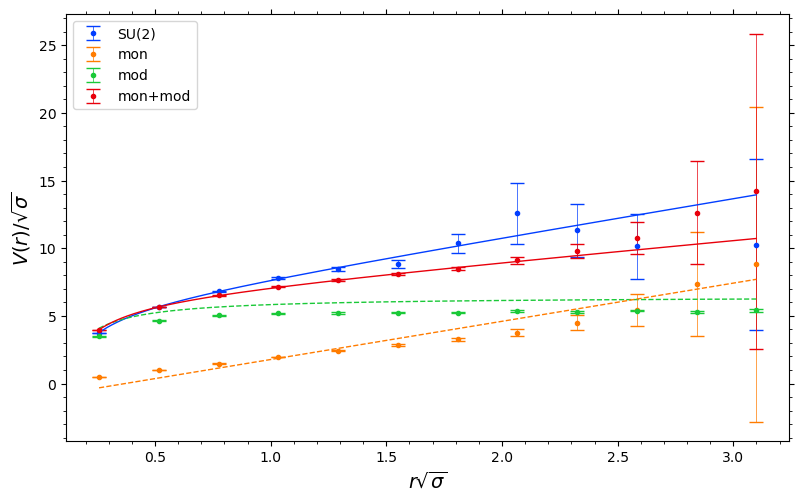

../../images/potential_decomposition/su2/gluodynamics/su2_suzuki/potential_decomposition_adjoint_beta=2.4.png


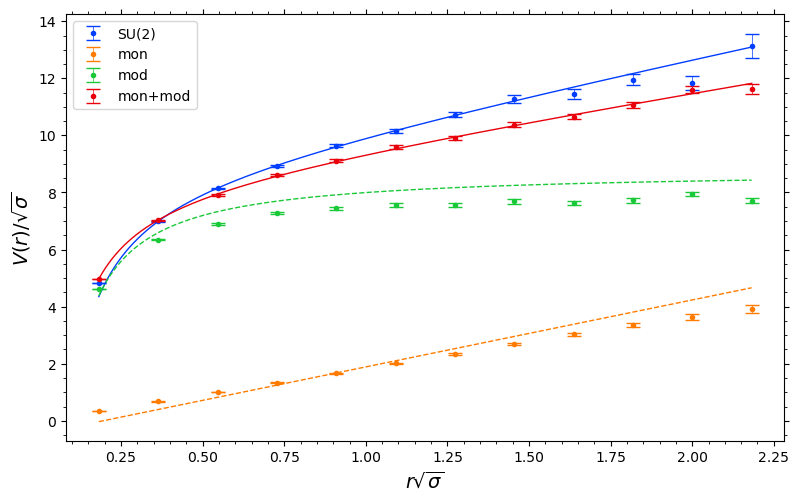

../../images/potential_decomposition/su2/gluodynamics/su2_suzuki/potential_decomposition_adjoint_beta=2.5.png


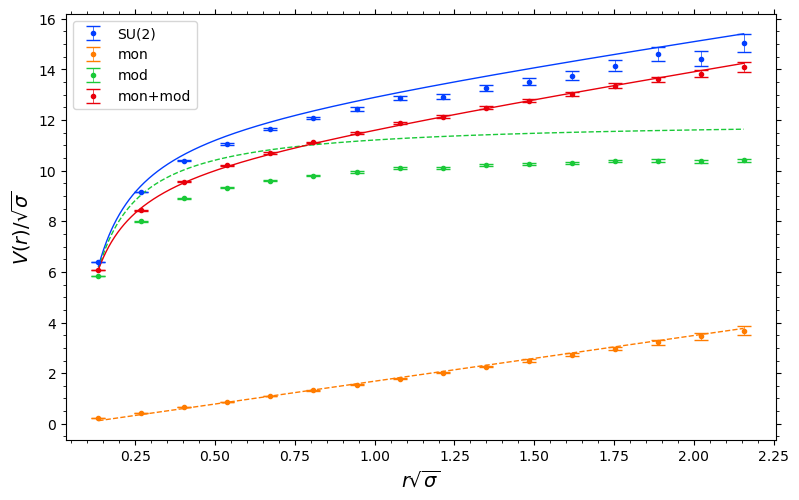

../../images/potential_decomposition/su2/gluodynamics/su2_suzuki/potential_decomposition_adjoint_beta=2.6.png


In [8]:
df = read_data_vitaly_adjoint()
df = df[(df['aV(r)'] != 0) & (df['T'] <= 8)]
sigma = {2.4: 0.258265, 2.5: 0.181839, 2.6: 0.1347252}
pool = {'df': df, 'filter_function': filter_beta_adjoint, 'custom_fit_func': fit_parameters_vitaly_adjoint}
plot_decomposition(remove_T_filter, fit_r_original_sum_custom, pool, 'adjoint', sigma)

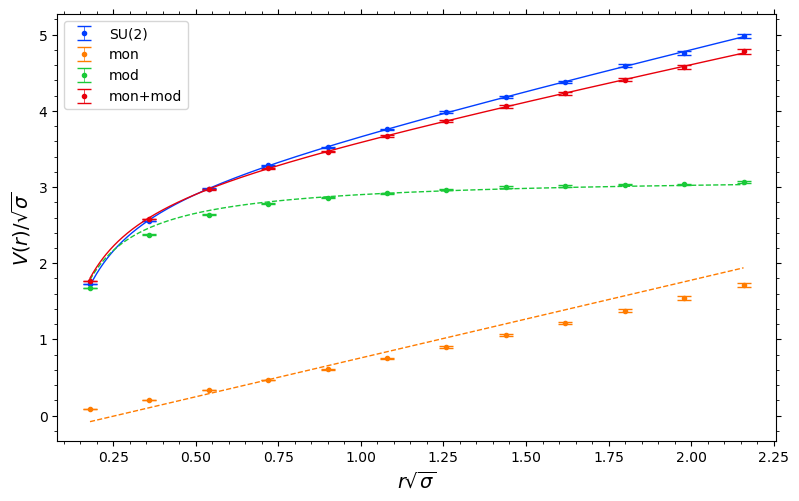

../../images/potential_decomposition/su2/gluodynamics/su2_suzuki/potential_decomposition_fundamental_beta=3.4.png


In [9]:
df = read_data_vitaly_improved_fundamental()
df = df[(df['aV(r)'] != 0) & (df['T'] <= 7)]
sigma = {3.4: 0.1798926}
pool = {'df': df, 'filter_function': filter_improved_fundamental}
plot_decomposition(remove_T_filter, fit_r_original_sum, pool, 'fundamental', sigma)

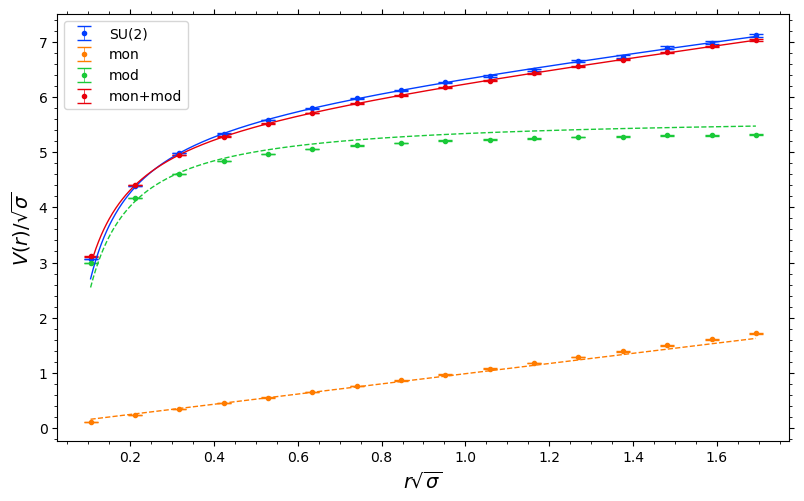

../../images/potential_decomposition/su2/gluodynamics/su2_suzuki/potential_decomposition_fundamental_beta=1.95.png


In [10]:
df = read_data_vitaly_QC2D_fundamental()
df = df[(df['aV(r)'] != 0) & (df['T'] <= 7)]
sigma = {1.95: 0.1058200}
pool = {'df': df}
plot_decomposition(remove_T_fit, fit_r_original_sum, pool, 'fundamental', sigma)